<a href="https://colab.research.google.com/github/isratrimii/Neural-Networks/blob/main/RNN_%26_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# LOAD DATASET
df = pd.read_csv('/content/drive/MyDrive/Data Mining Lab/Copy of Metro_Interstate_Traffic_Volume.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [8]:
# HANDLE MISSING VALUES
print(df.isna().sum())

df['holiday'] = df['holiday'].fillna(0)

df['holiday'] = df['holiday'].apply(
    lambda x: 1 if x != 0 else 0
)

print(df['holiday'].value_counts())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64
holiday
0    48143
1       61
Name: count, dtype: int64


In [9]:
# FEATURE ENGINEERING
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour

df['day_of_week'] = df['date_time'].dt.dayofweek

df['month'] = df['date_time'].dt.month

df['weekend'] = (
    df['day_of_week'] >= 5
).astype(int)

df = df.drop(
    columns=['date_time', 'weather_description']
)


In [10]:
# ONE HOT ENCODING
categorical_features = [
    'holiday',
    'weather_main'
]

df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [11]:
# NORMALIZATION
scaler = MinMaxScaler()

continuous_features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'day_of_week',
    'month'
]

df[continuous_features] = scaler.fit_transform(
    df[continuous_features]
)

In [12]:
# CREATE SEQUENCES
SEQ_LEN = 48

TARGET = 'traffic_volume'

features = df.drop(columns=[TARGET]).values

target = df[TARGET].values

X = []
y = []

for i in range(SEQ_LEN, len(df)):

    X.append(features[i-SEQ_LEN:i])

    y.append(target[i])

X = np.array(X)

y = np.array(y)

# Scale target values
y_scaler = MinMaxScaler()

y_scaled = y_scaler.fit_transform(
    y.reshape(-1,1)
)

print("X shape:", X.shape)

print("y shape:", y.shape)

X shape: (48156, 48, 19)
y shape: (48156,)


In [13]:
# TRAIN TEST SPLIT
train_size = int(0.7 * len(X))

val_size = int(0.15 * len(X))

X_train = X[:train_size]

y_train = y_scaled[:train_size]

X_val = X[
    train_size:train_size+val_size
]

y_val = y_scaled[
    train_size:train_size+val_size
]

X_test = X[train_size+val_size:]

y_test = y_scaled[train_size+val_size:]

print("X_train shape:", X_train.shape)

print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)

print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)

print("y_test shape:", y_test.shape)

X_train shape: (33709, 48, 19)
y_train shape: (33709, 1)
X_val shape: (7223, 48, 19)
y_val shape: (7223, 1)
X_test shape: (7224, 48, 19)
y_test shape: (7224, 1)


In [14]:
# BUILD RNN MODEL
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        32,
        input_shape=(
            SEQ_LEN,
            X.shape[2]
        ),
        activation='tanh'
    )
)

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# TRAIN RNN MODEL
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)



Epoch 1/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0369 - val_loss: 0.0207
Epoch 2/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0207 - val_loss: 0.0151
Epoch 3/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0183 - val_loss: 0.0145
Epoch 4/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0169 - val_loss: 0.0145
Epoch 5/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0156 - val_loss: 0.0142
Epoch 6/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0147 - val_loss: 0.0136
Epoch 7/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0136 - val_loss: 0.0102
Epoch 8/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0128 - val_loss: 0.0103
Epoch 9/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0121 - val_loss: 0.0094
Epoch 10/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0114 - val_loss: 0.0090
Epoch 11/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0111 - val_loss: 0.0099
Epoch 12/20
10

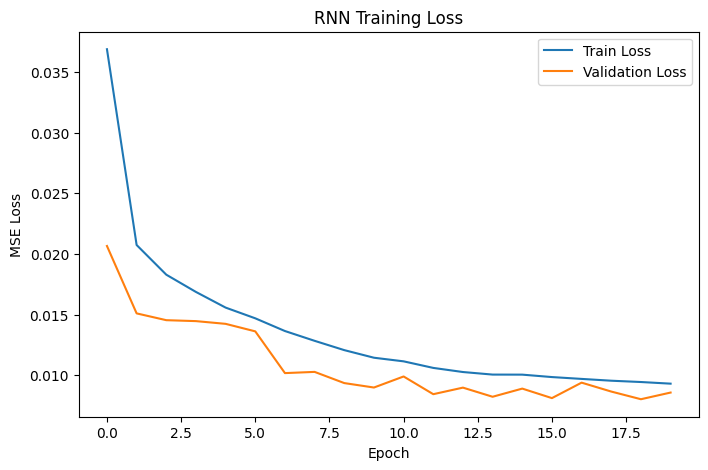

In [16]:
# RNN LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    rnn_history.history['loss'],
    label='Train Loss'
)

plt.plot(
    rnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('RNN Training Loss')

plt.xlabel('Epoch')

plt.ylabel('MSE Loss')

plt.legend()

plt.show()

In [17]:
# BUILD LSTM MODEL
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(
            SEQ_LEN,
            X.shape[2]
        ),
        activation='tanh'
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# EARLY STOPPING

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [19]:
# TRAIN LSTM MODEL
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)


Epoch 1/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0276 - val_loss: 0.0180
Epoch 2/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0169 - val_loss: 0.0123
Epoch 3/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0140 - val_loss: 0.0094
Epoch 4/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - loss: 0.0124 - val_loss: 0.0086
Epoch 5/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - loss: 0.0112 - val_loss: 0.0085
Epoch 6/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0103 - val_loss: 0.0080
Epoch 7/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - loss: 0.0095 - val_loss: 0.0076
Epoch 8/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - loss: 0.0090 - val_loss: 0.0067
Epoch 9/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0086 - val_loss: 0.0069
Epoch 10/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - loss: 0.0082 - val_loss: 0.0071
Epoch 11/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 0.0079 - val_loss: 0.0070
Epoch 12

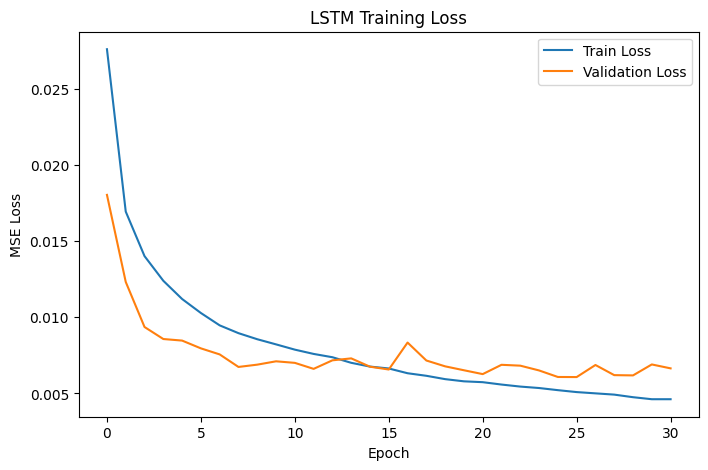

In [20]:
# LSTM LOSS GRAPH
plt.figure(figsize=(8,5))

plt.plot(
    lstm_history.history['loss'],
    label='Train Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training Loss')

plt.xlabel('Epoch')

plt.ylabel('MSE Loss')

plt.legend()

plt.show()

In [21]:
# RNN PREDICTIONS
y_pred_rnn_scaled = rnn_model.predict(X_test)

y_pred_rnn = y_scaler.inverse_transform(
    y_pred_rnn_scaled
)


226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [22]:
# LSTM PREDICTIONS
y_pred_lstm_scaled = lstm_model.predict(X_test)

y_pred_lstm = y_scaler.inverse_transform(
    y_pred_lstm_scaled
)

226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [23]:
# ORIGINAL TEST VALUES

y_test_original = y_scaler.inverse_transform(
    y_test
)


In [24]:
# MODEL EVALUATION

mse_rnn = mean_squared_error(
    y_test_original,
    y_pred_rnn
)

print(f"RNN Test MSE: {mse_rnn:.2f}")

mse_lstm = mean_squared_error(
    y_test_original,
    y_pred_lstm
)

print(f"LSTM Test MSE: {mse_lstm:.2f}")

RNN Test MSE: 382557.12
LSTM Test MSE: 318477.92


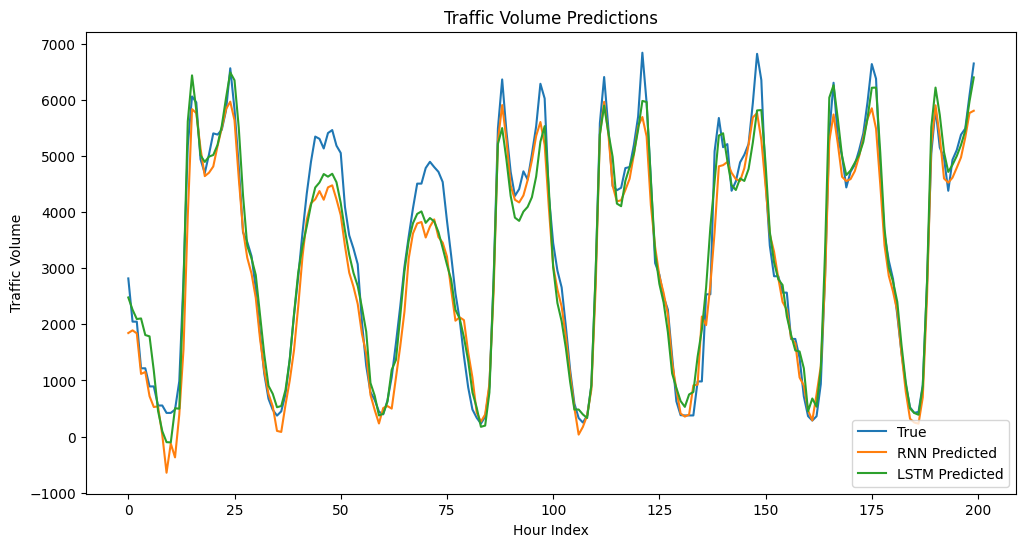

In [25]:

# ACTUAL VS PREDICTED GRAPH

plt.figure(figsize=(12,6))

plt.plot(
    y_test_original[:200],
    label='True'
)

plt.plot(
    y_pred_rnn[:200],
    label='RNN Predicted'
)

plt.plot(
    y_pred_lstm[:200],
    label='LSTM Predicted'
)

plt.title('Traffic Volume Predictions')

plt.xlabel('Hour Index')

plt.ylabel('Traffic Volume')

plt.legend()

plt.show()